In [1]:
import os
import pandas as pd

# The exact path from your screenshot
base_path = '/kaggle/input/datasets/bitsnpieces/ovarian-cancer-and-subtypes-dataset-histopathology/OvarianCancer'

data = []
# We use os.walk to go into every single subfolder
for root, dirs, files in os.walk(base_path):
    for file in files:
        # Check for all common image types in histopathology
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            # The folder name is the label (e.g., 'Serous')
            label = os.path.basename(root)
            path = os.path.join(root, file)
            data.append({'path': path, 'label': label})

df = pd.DataFrame(data)

# Verification
print(f"Total images found: {len(df)}") 
print(df['label'].value_counts())

Total images found: 498
label
Non_Cancerous    100
Serous           100
Mucinous         100
Clear_Cell       100
Endometri         98
Name: count, dtype: int64


In [2]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

# Output folder (Kaggle working directory)
output_path = '/kaggle/working/Augmented_OvarianCancer'

# Create base output directory
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Image augmentation settings (same as your paper)
datagen = ImageDataGenerator(
    rotation_range=40,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.5, 1.5),
    fill_mode='nearest'
)

print("Starting augmentation process...")

total_count = 0
category_stats = {}

# Get unique labels from your dataframe
categories = df['label'].unique()

for category in categories:
    # Filter dataframe for this category
    df_cat = df[df['label'] == category]

    # Create category folder inside output
    output_dir = os.path.join(output_path, category)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    print(f"Processing category: {category} ({len(df_cat)} original images)")

    category_count = 0

    for idx, row in df_cat.iterrows():
        img_path = row['path']

        try:
            # Load and resize image
            img = load_img(img_path, target_size=(227, 227))
            x = img_to_array(img)
            x = x.reshape((1,) + x.shape)

            # Generate 50 augmented images
            i = 0
            for batch in datagen.flow(
                x,
                batch_size=1,
                save_to_dir=output_dir,
                save_prefix=category[:3],
                save_format='jpg'
            ):
                i += 1
                category_count += 1
                if i >= 50:
                    break

        except Exception as e:
            print(f"Error processing {img_path}: {e}")

    category_stats[category] = category_count
    total_count += category_count

# Final Summary
print("\n" + "="*40)
print("AUGMENTATION COMPLETE")
print("="*40)
for cat, count in category_stats.items():
    print(f"{cat.ljust(15)}: {count:,} images")
print("-" * 40)
print(f"TOTAL IMAGES   : {total_count:,}")
print("=" * 40)

2026-03-27 08:42:48.970578: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774600969.424621      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774600969.591241      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774600970.892196      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774600970.892233      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774600970.892235      55 computation_placer.cc:177] computation placer alr

Starting augmentation process...
Processing category: Non_Cancerous (100 original images)
Processing category: Endometri (98 original images)
Processing category: Serous (100 original images)
Processing category: Mucinous (100 original images)
Processing category: Clear_Cell (100 original images)

AUGMENTATION COMPLETE
Non_Cancerous  : 5,000 images
Endometri      : 4,900 images
Serous         : 5,000 images
Mucinous       : 5,000 images
Clear_Cell     : 5,000 images
----------------------------------------
TOTAL IMAGES   : 24,900


In [3]:
import os

# Path where augmented images are saved in Kaggle
kaggle_aug_path = "/kaggle/working/Augmented_OvarianCancer"

total = 0

print("\nImage count per category:\n")

for folder in os.listdir(kaggle_aug_path):
    folder_path = os.path.join(kaggle_aug_path, folder)

    if os.path.isdir(folder_path):
        count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        print(f"{folder.ljust(15)} : {count:,}")
        total += count

print("-" * 40)
print(f"TOTAL IMAGES      : {total:,}")
print("-" * 40)


Image count per category:

Serous          : 3,952
Clear_Cell      : 3,917
Non_Cancerous   : 3,935
Endometri       : 3,863
Mucinous        : 3,953
----------------------------------------
TOTAL IMAGES      : 19,620
----------------------------------------


In [4]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Source: your augmented dataset (created earlier in Kaggle)
SOURCE_DIR = "/kaggle/working/Augmented_OvarianCancer"

# Destination: split dataset
BASE_DIR = "/kaggle/working/split_data"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# Create base folders
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

classes = os.listdir(SOURCE_DIR)

for cls in classes:
    cls_path = os.path.join(SOURCE_DIR, cls)

    # Skip non-folder files (safety)
    if not os.path.isdir(cls_path):
        continue

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]

    # 70% Train, 30% temp
    train_imgs, temp_imgs = train_test_split(
        images, test_size=0.30, random_state=42
    )

    # Split remaining → 15% Val + 15% Test
    val_imgs, test_imgs = train_test_split(
        temp_imgs, test_size=0.50, random_state=42
    )

    # Create class folders
    for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

    # Copy files
    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(TRAIN_DIR, cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(VAL_DIR, cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(TEST_DIR, cls, img)
        )

print("✅ 70/15/15 dataset split completed!")

✅ 70/15/15 dataset split completed!


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Kaggle path
BASE_DIR = "/kaggle/working/split_data"

TRAIN_PATH = BASE_DIR + "/train"
VAL_PATH   = BASE_DIR + "/val"
TEST_PATH  = BASE_DIR + "/test"

# Generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# =================
# TRAIN (70%)
# =================
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(227, 227),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# =================
# VALIDATION (15%)
# =================
val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(227, 227),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# =================
# TEST (15%)
# =================
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(227, 227),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # important for evaluation
)

print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Testing samples:", test_generator.samples)

Found 13732 images belonging to 5 classes.
Found 2943 images belonging to 5 classes.
Found 2945 images belonging to 5 classes.
Training samples: 13732
Validation samples: 2943
Testing samples: 2945


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

NUM_CLASSES = train_generator.num_classes

# ================================
# 1. Load Pretrained VGG19 Backbone
# ================================
base_model = VGG19(
    weights="imagenet",
    include_top=False,
    input_shape=(227, 227, 3)
)

# Freeze backbone
for layer in base_model.layers:
    layer.trainable = False

# ================================
# 2. Custom Classification Head
# ================================
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)   # 🔥 improves stability

x = Dense(512, activation="elu")(x)
x = Dropout(0.4)(x)

x = Dense(256, activation="elu")(x)
x = Dropout(0.3)(x)

outputs = Dense(NUM_CLASSES, activation="softmax")(x)

vgg19_model = Model(inputs=base_model.input, outputs=outputs)

# ================================
# 3. Compile Model
# ================================
vgg19_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

vgg19_model.summary()

I0000 00:00:1774601600.825920      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774601600.832500      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 227, 227, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 227, 227, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 113, 113, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 113, 113, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,421,701 (77.90 MB)

 Trainable params: 396,293 (1.51 MB)

 Non-trainable params: 20,025,408 (76.39 MB)

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "vgg19_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)


In [9]:
history_vgg = vgg19_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint, early_stop, lr_scheduler]
)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1774601616.076916     147 service.cc:152] XLA service 0x7b3744007130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774601616.076958     147 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774601616.076962     147 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774601616.846553     147 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/430 ━━━━━━━━━━━━━━━━━━━━ 2:01:38 17s/step - accuracy: 0.3125 - loss: 1.8088

I0000 00:00:1774601630.671825     147 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.3283 - loss: 1.7328
Epoch 1: val_accuracy improved from -inf to 0.65172, saving model to vgg19_best.keras
430/430 ━━━━━━━━━━━━━━━━━━━━ 153s 317ms/step - accuracy: 0.3284 - loss: 1.7324 - val_accuracy: 0.6517 - val_loss: 1.1379 - learning_rate: 1.0000e-05
Epoch 2/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.5237 - loss: 1.3340
Epoch 2: val_accuracy improved from 0.65172 to 0.71424, saving model to vgg19_best.keras
430/430 ━━━━━━━━━━━━━━━━━━━━ 128s 298ms/step - accuracy: 0.5237 - loss: 1.3338 - val_accuracy: 0.7142 - val_loss: 0.9694 - learning_rate: 1.0000e-05
Epoch 3/30
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.5917 - loss: 1.2062
Epoch 3: val_accuracy improved from 0.71424 to 0.74550, saving model to vgg19_best.keras
430/430 ━━━━━━━━━━━━━━━━━━━━ 130s 301ms/step - accuracy: 0.5917 - loss: 1.2062 - val_accuracy: 0.7455 - val_loss: 0.9138 - learning_rate: 1.0000e-05
Epoch 4/30
430/430 ━━━━━━━━━━━━━━━━━

In [10]:
from tensorflow.keras.models import load_model
import numpy as np
import os

# =========================================
# 1. Find best epoch from training history
# =========================================

best_epoch_idx = np.argmax(history_vgg.history['val_accuracy'])
best_epoch_num = best_epoch_idx + 1

best_val_acc = history_vgg.history['val_accuracy'][best_epoch_idx]
best_val_loss = history_vgg.history['val_loss'][best_epoch_idx]
best_train_acc = history_vgg.history['accuracy'][best_epoch_idx]
best_train_loss = history_vgg.history['loss'][best_epoch_idx]

print("-" * 40)
print(f"🏆 BEST VGG19 TRAINING RESULTS (Epoch {best_epoch_num})")
print("-" * 40)
print(f"Training Accuracy   : {best_train_acc*100:.2f}%")
print(f"Training Loss       : {best_train_loss:.4f}")
print(f"Validation Accuracy : {best_val_acc*100:.2f}%")
print(f"Validation Loss     : {best_val_loss:.4f}")
print("-" * 40)

# =========================================
# 2. Load BEST saved model (Kaggle path fix)
# =========================================

model_path = "/kaggle/working/vgg19_best.keras"

if not os.path.exists(model_path):
    print("❌ Model file not found! Check save path.")
else:
    best_model = load_model(model_path)

    # =========================================
    # 3. Evaluate on test set
    # =========================================
    test_loss, test_acc = best_model.evaluate(test_generator, verbose=0)

    print(f"Best Model Test Accuracy : {test_acc*100:.2f}%")
    print("-" * 40)

----------------------------------------
🏆 BEST VGG19 TRAINING RESULTS (Epoch 30)
----------------------------------------
Training Accuracy   : 82.33%
Training Loss       : 0.7807
Validation Accuracy : 89.40%
Validation Loss     : 0.6577
----------------------------------------
Best Model Test Accuracy : 90.53%
----------------------------------------


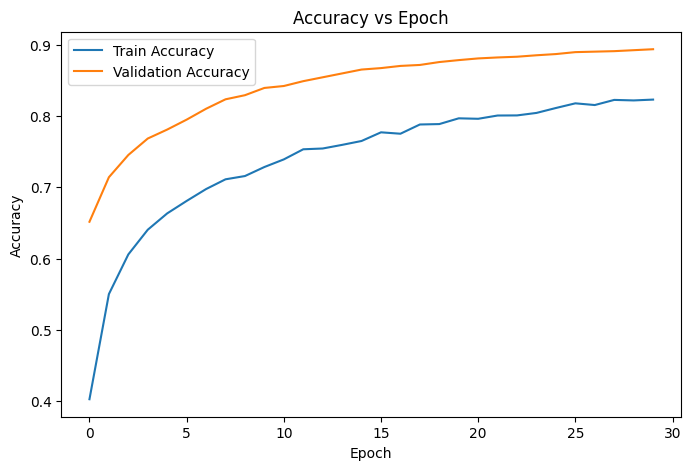

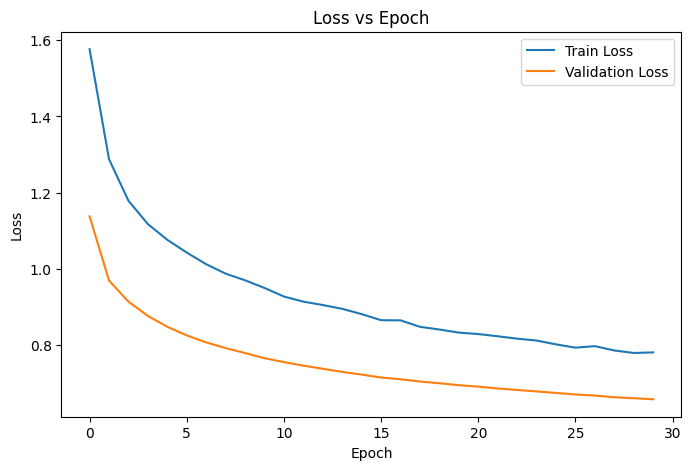

In [11]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [12]:
# Save full model in HDF5 format
vgg19_model.save("/kaggle/working/vgg19_model.h5")

print("✅ Model saved as vgg19_model.h5")

✅ Model saved as vgg19_model.h5


In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# Get true labels
# =========================================
y_true = test_generator.classes

# =========================================
# Predict probabilities
# =========================================
y_prob = vgg19_model.predict(test_generator)

# =========================================
# Predicted class labels
# =========================================
y_pred = np.argmax(y_prob, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())


93/93 ━━━━━━━━━━━━━━━━━━━━ 25s 255ms/step


In [14]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report:

               precision    recall  f1-score   support

   Clear_Cell       0.84      0.89      0.87       588
    Endometri       0.97      0.97      0.97       580
     Mucinous       0.87      0.88      0.88       593
Non_Cancerous       0.91      0.91      0.91       591
       Serous       0.94      0.88      0.91       593

     accuracy                           0.91      2945
    macro avg       0.91      0.91      0.91      2945
 weighted avg       0.91      0.91      0.91      2945



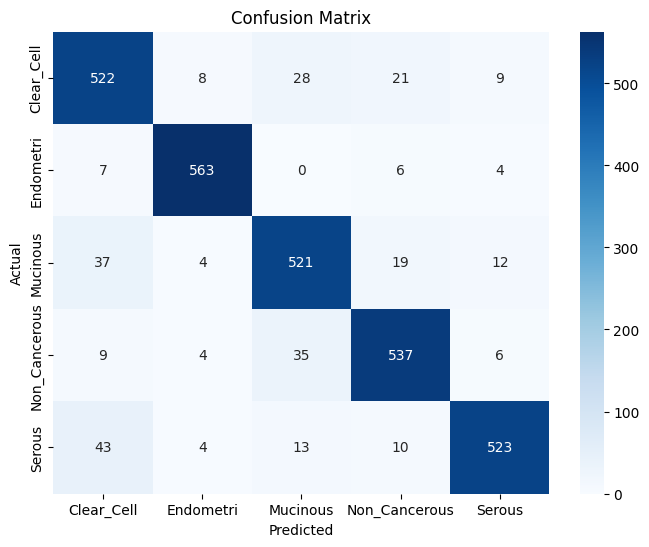

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


93/93 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step


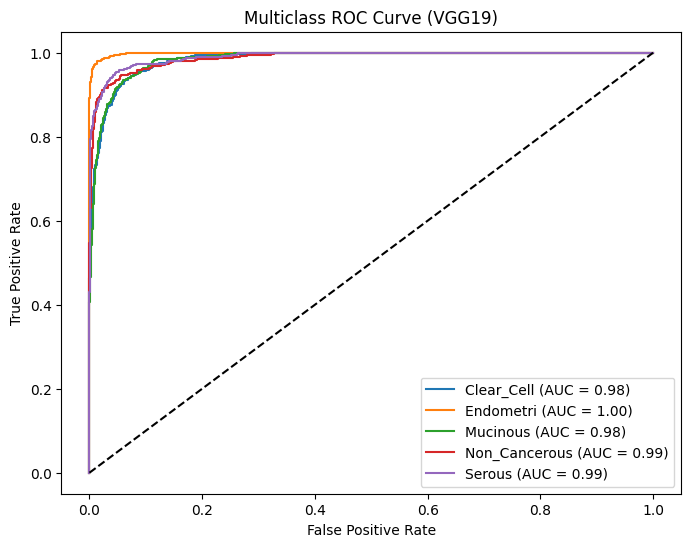

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# =========================================
# Predict probabilities on test set
# =========================================
y_prob = best_model.predict(test_generator)

# =========================================
# True labels
# =========================================
y_true = test_generator.classes

# =========================================
# Number of classes
# =========================================
num_classes = len(test_generator.class_indices)

# =========================================
# Binarize true labels (One-vs-Rest)
# =========================================
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# =========================================
# Class names
# =========================================
class_names = list(test_generator.class_indices.keys())

# =========================================
# Plot ROC curve for each class
# =========================================
plt.figure(figsize=(8,6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Random guess line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (VGG19)")
plt.legend()
plt.show()


In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, rand_score

# =========================================
# 1. Get true labels + predictions from CNN
# =========================================

# True labels from test generator
y_true = test_generator.classes

# Predict probabilities
y_prob = best_model.predict(test_generator)

# Convert probabilities → class labels
y_pred = np.argmax(y_prob, axis=1)

# =========================================
# 2. Confusion Matrix
# =========================================

cm = confusion_matrix(y_true, y_pred)

# =========================================
# 3. Advanced Metric Function (unchanged logic)
# =========================================

def calculate_advanced_metrics(cm):
    num_classes = cm.shape[0]
    metrics = {}

    for i in range(num_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        fdr = fp / (fp + tp) if (fp + tp) > 0 else 0

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f_measure = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        numerator = (tp * tn) - (fp * fn)
        denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
        mcc = numerator / denominator if denominator > 0 else 0

        metrics[i] = {
            "Specificity": specificity,
            "FPR": fpr,
            "FNR": fnr,
            "NPV": npv,
            "FDR": fdr,
            "F-Measure": f_measure,
            "MCC": mcc
        }

    return metrics

# =========================================
# 4. Calculate Metrics
# =========================================

results = calculate_advanced_metrics(cm)

class_names = list(test_generator.class_indices.keys())

print(f"{'Category':<15} | {'Spec.':<6} | {'FPR':<6} | {'FNR':<6} | {'NPV':<6} | {'FDR':<6} | {'F-Meas':<7} | {'MCC':<6}")
print("-" * 90)

for i, cat in enumerate(class_names):
    m = results[i]
    print(f"{cat:<15} | {m['Specificity']:.3f} | {m['FPR']:.3f} | {m['FNR']:.3f} | {m['NPV']:.3f} | {m['FDR']:.3f} | {m['F-Measure']:.3f} | {m['MCC']:.3f}")

# =========================================
# 5. Rand Index (overall clustering similarity)
# =========================================

rand_index = rand_score(y_true, y_pred)
print(f"\nOverall Rand Index: {rand_index:.4f}")


93/93 ━━━━━━━━━━━━━━━━━━━━ 22s 239ms/step
Category        | Spec.  | FPR    | FNR    | NPV    | FDR    | F-Meas  | MCC   
------------------------------------------------------------------------------------------
Clear_Cell      | 0.959 | 0.041 | 0.112 | 0.972 | 0.155 | 0.866 | 0.832
Endometri       | 0.992 | 0.008 | 0.029 | 0.993 | 0.034 | 0.968 | 0.960
Mucinous        | 0.968 | 0.032 | 0.121 | 0.969 | 0.127 | 0.876 | 0.844
Non_Cancerous   | 0.976 | 0.024 | 0.091 | 0.977 | 0.094 | 0.907 | 0.884
Serous          | 0.987 | 0.013 | 0.118 | 0.971 | 0.056 | 0.912 | 0.891

Overall Rand Index: 0.9294


In [19]:
from IPython.display import FileLink

# Create download links
display(FileLink('/kaggle/working/vgg19_model.h5'))
display(FileLink('/kaggle/working/vgg19_best.keras'))

/kaggle/working/vgg19_model.h5

/kaggle/working/vgg19_best.keras

In [ ]:
import shutil

# Create zip file
shutil.make_archive('/kaggle/working/vgg19_models', 'zip', '/kaggle/working')

# Download link
from IPython.display import FileLink
FileLink('/kaggle/working/vgg19_models.zip')